In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split, cross_val_score
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.pipeline import Pipeline

# Шаг 1. Изучение примеров

Для решения поставленной задачи были изучены приведённые примеры выполнения

# Шаг 2. Загрузка и подготовка данных

In [3]:
data = pd.read_csv('D:/Python/ML_labs/data/post_diamonds.csv')
data

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,0,1,6,61.5,55.0,326,3.95,3.98,2.43
1,0.21,1,1,5,59.8,61.0,326,3.89,3.84,2.31
2,0.23,3,1,3,56.9,65.0,327,4.05,4.07,2.31
3,0.29,1,5,4,62.4,58.0,334,4.20,4.23,2.63
4,0.31,3,6,6,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53789,0.72,0,0,5,60.8,57.0,2757,5.75,5.76,3.50
53790,0.72,3,0,5,63.1,55.0,2757,5.69,5.75,3.61
53791,0.70,2,0,5,62.8,60.0,2757,5.66,5.68,3.56
53792,0.86,1,4,6,61.0,58.0,2757,6.15,6.12,3.74


In [4]:
data.describe()

,carat,cut,color,clarity,depth,table,price,x,y,z
count,53794.00000,53794.000000,53794.000000,53794.000000,53794.000000,53794.000000,53794.000000,53794.000000,53794.000000,53794.000000
mean,0.79778,1.095866,2.593914,3.948080,61.748080,57.458109,3933.065082,5.731956,5.735290,3.539960
std,0.47339,1.116098,1.701117,1.646857,1.429909,2.233679,3988.114460,1.118786,1.139601,0.701893
min,0.20000,0.000000,0.000000,0.000000,43.000000,43.000000,326.000000,3.730000,3.680000,1.070000
25%,0.40000,0.000000,1.000000,3.000000,61.000000,56.000000,951.000000,4.710000,4.720000,2.910000
50%,0.70000,1.000000,3.000000,4.000000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.04000,2.000000,4.000000,5.000000,62.500000,59.000000,5326.750000,6.540000,6.540000,4.030000
max,5.01000,4.000000,6.000000,7.000000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [5]:
y = data["price"]
x = data.drop(["price"], axis=1)

In [6]:
x

,carat,cut,color,clarity,depth,table,x,y,z
0,0.23,0,1,6,61.5,55.0,3.95,3.98,2.43
1,0.21,1,1,5,59.8,61.0,3.89,3.84,2.31
2,0.23,3,1,3,56.9,65.0,4.05,4.07,2.31
3,0.29,1,5,4,62.4,58.0,4.20,4.23,2.63
4,0.31,3,6,6,63.3,58.0,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...
53789,0.72,0,0,5,60.8,57.0,5.75,5.76,3.50
53790,0.72,3,0,5,63.1,55.0,5.69,5.75,3.61
53791,0.70,2,0,5,62.8,60.0,5.66,5.68,3.56
53792,0.86,1,4,6,61.0,58.0,6.15,6.12,3.74


In [7]:
y

0         326
1         326
2         327
3         334
4         335
         ... 
53789    2757
53790    2757
53791    2757
53792    2757
53793    2757
Name: price, Length: 53794, dtype: int64

In [8]:
# Разделение данных на обучающую и тестовую выборку
x_train_raw, x_test_raw, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Масштабирование исходных признаков
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train_raw)
x_test = scaler.transform(x_test_raw)

# Создание простых одномерных данных для монотонной регрессии
x_train_mono = x_train[:, [x.columns.get_loc('carat')]]
x_test_mono = x_test[:, [x.columns.get_loc('carat')]]  

# Создание полиномиальных признаков на основе масштабированных данных
poly = PolynomialFeatures(degree=2, include_bias=False)
x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.transform(x_test)

# Масштабирование полиномиальных признаков
scaler_poly = StandardScaler()
x_train_poly = scaler_poly.fit_transform(x_train_poly)
x_test_poly = scaler_poly.transform(x_test_poly)

# Проверяем размеры
x_train.shape, y_train.shape, x_test.shape, y_test.shape, x_train_poly.shape, x_test_poly.shape

((43035, 9), (43035,), (10759, 9), (10759,), (43035, 54), (10759, 54))

# Шаг 3. Решение задачи регрессии

In [9]:
# фиксация рандомного состояния для воспроизводимости
random_state = 42

In [10]:
# GridSearchCV
param_grid_lasso = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}
grid_lasso = GridSearchCV(Lasso(random_state=random_state, max_iter=5000), param_grid_lasso, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_lasso.fit(x_train, y_train)
print("Lasso GridSearchCV best params:", grid_lasso.best_params_)
print("Lasso GridSearchCV best RMSE:", np.sqrt(-grid_lasso.best_score_))

# RandomizedSearchCV
param_dist_lasso = {'alpha': np.logspace(-3, 2, 50)}
rand_lasso = RandomizedSearchCV(Lasso(random_state=random_state, max_iter=5000), param_dist_lasso, n_iter=10, cv=5, scoring='neg_mean_squared_error', random_state=random_state, n_jobs=-1)
rand_lasso.fit(x_train, y_train)
print("Lasso RandomizedSearchCV best params:", rand_lasso.best_params_)
print("Lasso RandomizedSearchCV best RMSE:", np.sqrt(-rand_lasso.best_score_))

def objective_lasso(trial):
    alpha = trial.suggest_float('alpha', 0.001, 100, log=True)
    model = Lasso(alpha=alpha, random_state=random_state, max_iter=5000)
    score = cross_val_score(model, x_train, y_train, cv=5, scoring='neg_mean_squared_error').mean()
    return score

study_lasso = optuna.create_study(direction='maximize')
study_lasso.optimize(objective_lasso, n_trials=50, n_jobs=-1)
print("Lasso Optuna best params:", study_lasso.best_params)
print("Lasso Optuna best RMSE:", np.sqrt(-study_lasso.best_value))

Lasso GridSearchCV best params: {'alpha': 1}
Lasso GridSearchCV best RMSE: 1222.90098367868
Lasso RandomizedSearchCV best params: {'alpha': np.float64(1.8420699693267164)}
Lasso RandomizedSearchCV best RMSE: 1222.7012691489592
Lasso Optuna best params: {'alpha': 1.8699401543449452}
Lasso Optuna best RMSE: 1222.702037372444


In [11]:
# GridSearchCV
param_grid_ridge = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}
grid_ridge = GridSearchCV(Ridge(random_state=random_state), param_grid_ridge, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_ridge.fit(x_train, y_train)
print("Ridge GridSearchCV best params:", grid_ridge.best_params_)
print("Ridge GridSearchCV best RMSE:", np.sqrt(-grid_ridge.best_score_))

# RandomizedSearchCV
param_dist_ridge = {'alpha': np.logspace(-3, 2, 50)}
rand_ridge = RandomizedSearchCV(Ridge(random_state=random_state), param_dist_ridge, n_iter=10, cv=5, scoring='neg_mean_squared_error', random_state=random_state, n_jobs=-1)
rand_ridge.fit(x_train, y_train)
print("Ridge RandomizedSearchCV best params:", rand_ridge.best_params_)
print("Ridge RandomizedSearchCV best RMSE:", np.sqrt(-rand_ridge.best_score_))

# Optuna
def objective_ridge(trial):
    alpha = trial.suggest_float('alpha', 1e-3, 1e2, log=True)
    model = Ridge(alpha=alpha, random_state=random_state)
    score = cross_val_score(model, x_train, y_train, cv=5, scoring='neg_mean_squared_error').mean()
    return score

study_ridge = optuna.create_study(direction='maximize')
study_ridge.optimize(objective_ridge, n_trials=50, n_jobs=-1)
print("Ridge Optuna best params:", study_ridge.best_params)
print("Ridge Optuna best RMSE:", np.sqrt(-study_ridge.best_value))

Ridge GridSearchCV best params: {'alpha': 10}
Ridge GridSearchCV best RMSE: 1223.5293184903371
Ridge RandomizedSearchCV best params: {'alpha': np.float64(39.06939937054621)}
Ridge RandomizedSearchCV best RMSE: 1223.501010771967
Ridge Optuna best params: {'alpha': 25.241424867460356}
Ridge Optuna best RMSE: 1223.4376316409728


In [12]:
# GridSearchCV
param_grid_elastic = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100],
                      'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]}
grid_elastic = GridSearchCV(ElasticNet(random_state=random_state), param_grid=param_grid_elastic, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_elastic.fit(x_train, y_train)
print("ElasticNet GridSearchCV best params:", grid_elastic.best_params_)
print("ElasticNet GridSearchCV best RMSE:", np.sqrt(-grid_elastic.best_score_))

# RandomizedSearchCV
param_dist_elastic = {'alpha': np.logspace(-3, 2, 50),
                      'l1_ratio': np.linspace(0, 1, 50)}
rand_elastic = RandomizedSearchCV(ElasticNet(random_state=random_state), param_distributions=param_dist_elastic, n_iter=10, cv=5, scoring='neg_mean_squared_error', random_state=random_state, n_jobs=-1)
rand_elastic.fit(x_train, y_train)
print("ElasticNet RandomizedSearchCV best params:", rand_elastic.best_params_)
print("ElasticNet RandomizedSearchCV best RMSE:", np.sqrt(-rand_elastic.best_score_))

# Optuna
def objective_elastic(trial):
    alpha = trial.suggest_float('alpha', 1e-3, 1e2, log=True)
    l1_ratio = trial.suggest_float('l1_ratio', 0.0, 1.0)
    model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, random_state=random_state)
    score = cross_val_score(model, x_train, y_train, cv=5, scoring='neg_mean_squared_error', n_jobs=-1).mean()
    return score

study_elastic = optuna.create_study(direction='maximize')
study_elastic.optimize(objective_elastic, n_trials=50, n_jobs=-1)
print("ElasticNet Optuna best params:", study_elastic.best_params)
print("ElasticNet Optuna best RMSE:", np.sqrt(-study_elastic.best_value))

d:\Python\ML_labs\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.160e+10, tolerance: 6.916e+07
  model = cd_fast.enet_coordinate_descent(


ElasticNet GridSearchCV best params: {'alpha': 0.001, 'l1_ratio': 0.3}
ElasticNet GridSearchCV best RMSE: 1223.4319549435252


d:\Python\ML_labs\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.213e+10, tolerance: 6.916e+07
  model = cd_fast.enet_coordinate_descent(


ElasticNet RandomizedSearchCV best params: {'l1_ratio': np.float64(0.6122448979591836), 'alpha': np.float64(0.004094915062380427)}
ElasticNet RandomizedSearchCV best RMSE: 1223.7125905646324
ElasticNet Optuna best params: {'alpha': 0.002183419021890954, 'l1_ratio': 0.6572558012453984}
ElasticNet Optuna best RMSE: 1223.4312321267955


In [13]:
# простая линейная регрессия без регуляризации
model_s_lr = LinearRegression()
# простая линейная регрессия L-1 регуляризация
model_s_ridge = Lasso(**study_lasso.best_params, random_state=random_state)
# простая линейная регрессия L-2 регуляризация
model_s_lasso = Ridge(**study_ridge.best_params, random_state=random_state)
# простая линейная регрессия L-1 + L-2 регуляризация
model_s_elastic = ElasticNet(**study_elastic.best_params, random_state=random_state)

# множественная линейная регрессия без регуляризации
model_lr = LinearRegression()
# множественная линейная регрессия L-1 регуляризация
model_ridge = Lasso(**study_lasso.best_params, random_state=random_state)
# множественная линейная регрессия L-2 регуляризация
model_lasso = Ridge(**study_ridge.best_params, random_state=random_state)
# множественная линейная регрессия L-1 + L-2 регуляризация
model_elastic = ElasticNet(**study_elastic.best_params, random_state=random_state)

# полиномиальная линейная регрессия без регуляризации
model_p_lr = LinearRegression()
# полиномиальная линейная регрессия L-1 регуляризация
model_p_ridge = Lasso(**study_lasso.best_params, random_state=random_state)
# полиномиальная линейная регрессия L-2 регуляризация
model_p_lasso = Ridge(**study_ridge.best_params, random_state=random_state, max_iter=8000, tol=1e-3)
# полиномиальная линейная регрессия L-1 + L-2 регуляризация
model_p_elastic = ElasticNet(**study_elastic.best_params, random_state=random_state, max_iter=8000, tol=1e-3)

In [14]:
# обучение моделей простой регрессии
model_s_lr.fit(x_train_mono, y_train)
model_s_lasso.fit(x_train_mono, y_train)
model_s_ridge.fit(x_train_mono, y_train)
model_s_elastic.fit(x_train_mono, y_train)

# обучение моделей множественнной регрессии
model_lr.fit(x_train, y_train)
model_lasso.fit(x_train, y_train)
model_ridge.fit(x_train, y_train)
model_elastic.fit(x_train, y_train)

# обучение модели полиномиальной регрессии
model_p_lr.fit(x_train_poly, y_train)
model_p_lasso.fit(x_train_poly, y_train)
model_p_ridge.fit(x_train_poly, y_train)
model_p_elastic.fit(x_train_poly, y_train)

d:\Python\ML_labs\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.811e+10, tolerance: 6.916e+07
  model = cd_fast.enet_coordinate_descent(
d:\Python\ML_labs\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.213e+08, tolerance: 6.916e+07
  model = cd_fast.enet_coordinate_descent(
d:\Python\ML_labs\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.154e+09, tolerance: 6.9

ElasticNet(alpha=0.002183419021890954, l1_ratio=0.6572558012453984,
           max_iter=8000, random_state=42, tol=0.001)

In [15]:
all_models = {
    'Simple Linear Regression': model_s_lr,
    'Simple Lasso': model_s_lasso,
    'Simple Ridge': model_s_ridge,
    'Simple ElasticNet': model_s_elastic,
    'Linear Regression': model_lr,
    'Lasso': model_lasso,
    'Ridge': model_ridge,
    'ElasticNet': model_elastic,
    'Poly Linear Regression': model_p_lr,
    'Poly Lasso': model_p_lasso,
    'Poly Ridge': model_p_ridge,
    'Poly ElasticNet': model_p_elastic
}

In [16]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler_poly', StandardScaler()),
    ('lasso', Lasso(**study_ridge.best_params, random_state=random_state, max_iter=8000, tol=1e-3))
])

pipe.fit(x, y)

y_pred = pipe.predict(x)

print(f"MAE: {mean_absolute_error(y, y_pred)}")
print(f"MSE: {mean_squared_error(y, y_pred)}")
print(f"RMSE: {np.sqrt(mean_squared_error(y, y_pred))}")
print(f"MAPE: {mean_absolute_percentage_error(y, y_pred)}")
print(f"R²: {r2_score(y, y_pred)}")
pipe

MAE: 461.1357984485536
MSE: 647389.7735532192
RMSE: 804.6053526749739
MAPE: 0.18005089868937538
R²: 0.9592958509676658


Pipeline(steps=[('scaler', StandardScaler()),
                ('poly', PolynomialFeatures(include_bias=False)),
                ('scaler_poly', StandardScaler()),
                ('lasso',
                 Lasso(alpha=25.241424867460356, max_iter=8000, random_state=42,
                       tol=0.001))])

# Шаг 4. Визуализация

In [17]:
def plot_predictions(y_test, y_pred, title):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.scatter(y_test, y_pred, alpha=0.5, label="Предсказания")
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--', label="Идеальные предсказания")
    plt.xlabel("Истинные значения")
    plt.ylabel("Предсказанные значения")
    plt.title(f"{title}: Предсказания vs Истинные значения")
    plt.legend()

    residuals = y_test - y_pred
    plt.subplot(1, 2, 2)
    plt.scatter(y_test, residuals, alpha=0.5, label="Остатки")
    plt.axhline(y=0, color='r', linestyle='--', label="Нулевой уровень")
    plt.xlabel("Истинные значения")
    plt.ylabel("Остатки")
    plt.title(f"{title}: Остатки vs Истинные значения")
    plt.legend()

    plt.show()

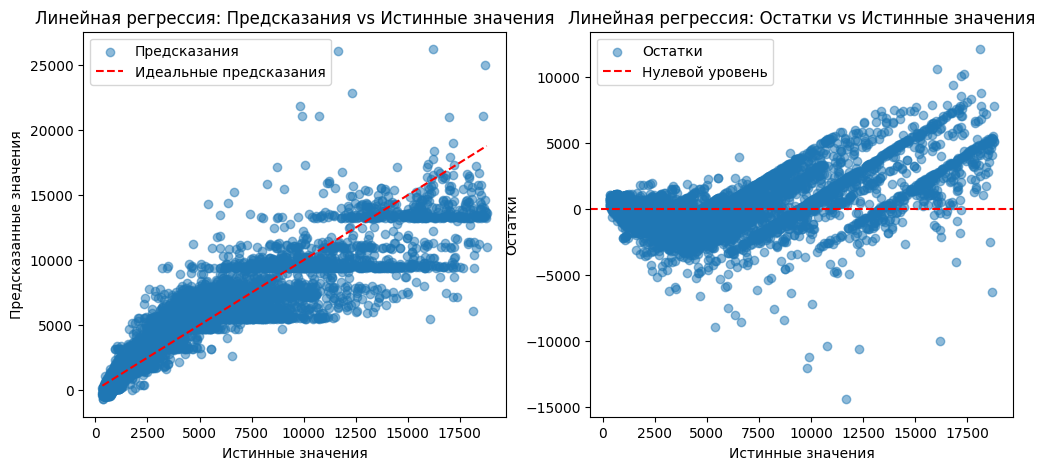

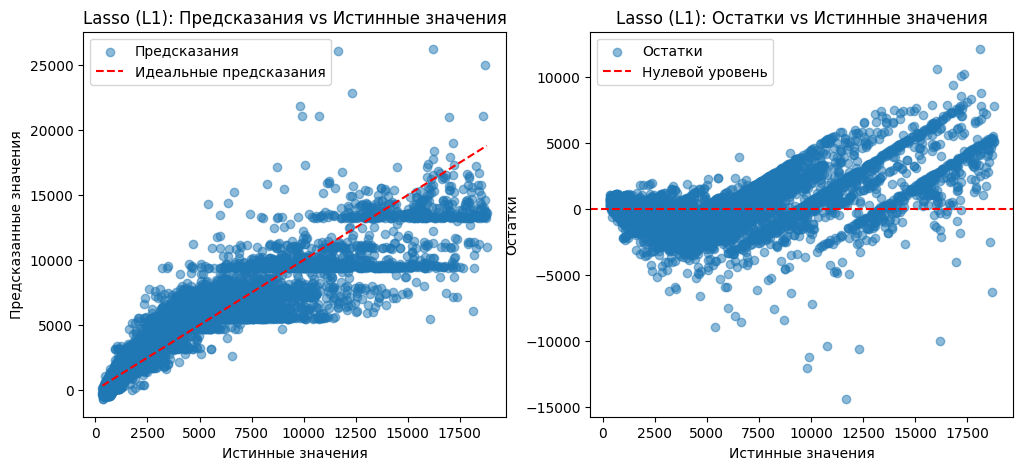

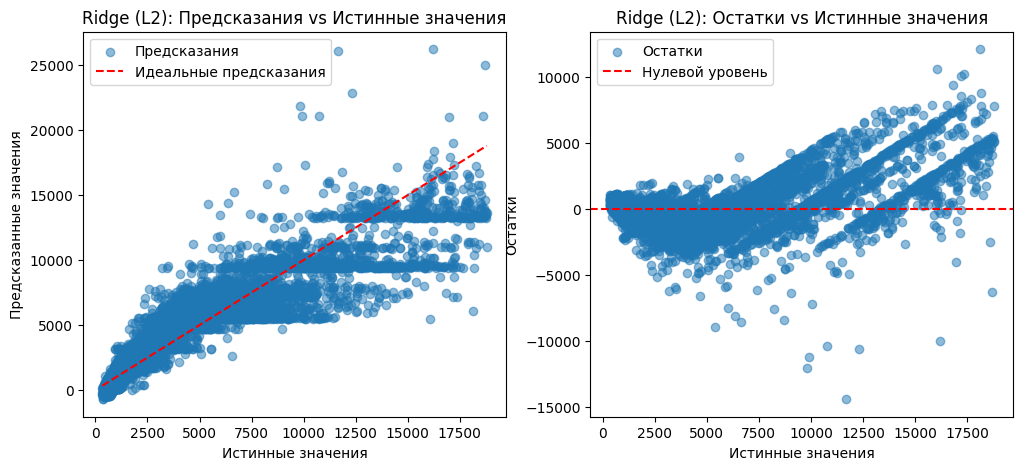

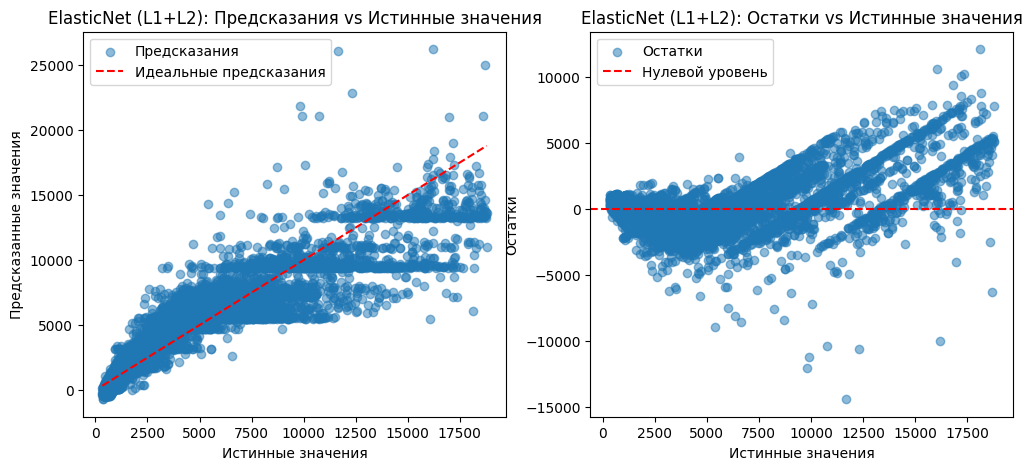

In [18]:
s_models = {
    "Линейная регрессия": model_s_lr,
    "Lasso (L1)": model_s_lasso,
    "Ridge (L2)": model_s_ridge,
    "ElasticNet (L1+L2)": model_s_elastic
}

# Построение графиков для каждой модели простой регрессии
for name, model in s_models.items():
    y_pred = model.predict(x_test_mono)
    plot_predictions(y_test, y_pred, name)

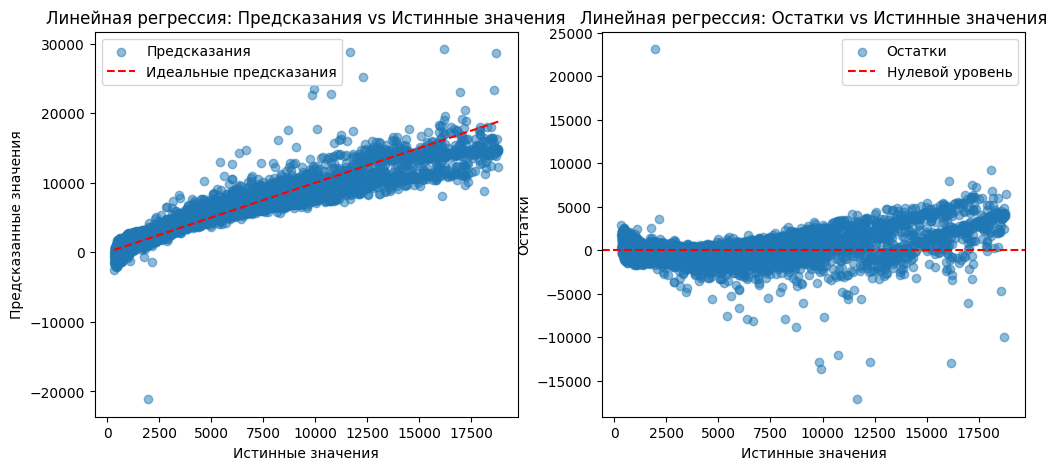

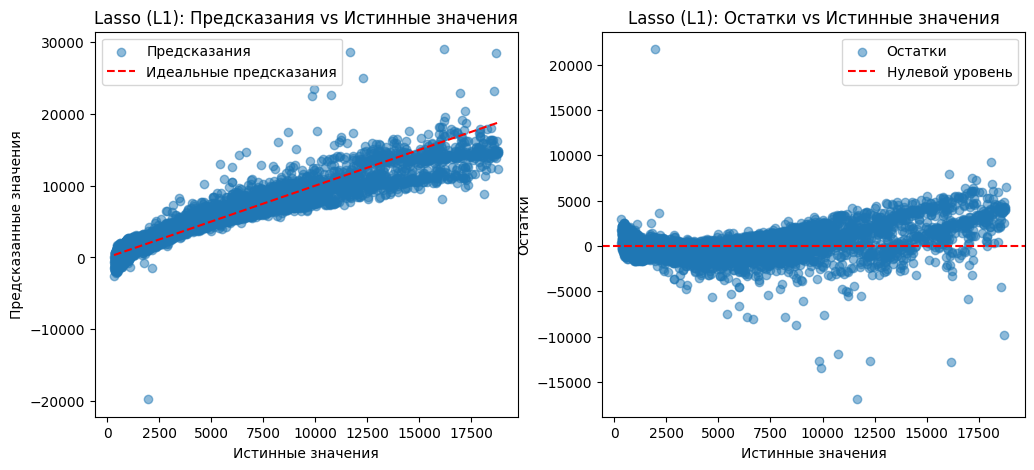

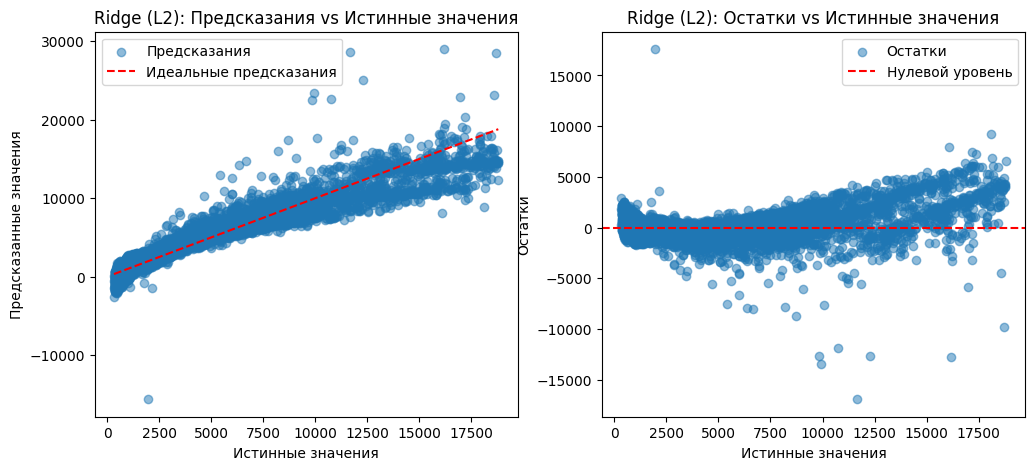

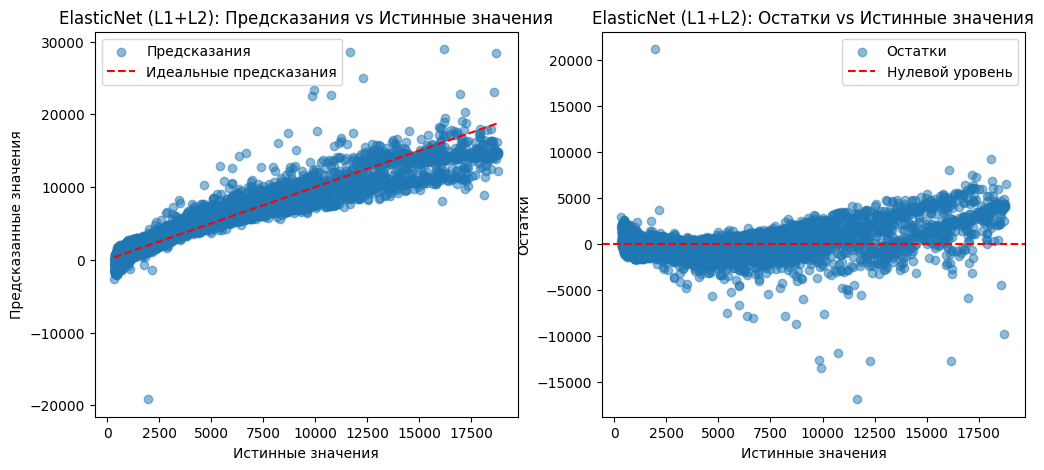

In [19]:
models = {
    "Линейная регрессия": model_lr,
    "Lasso (L1)": model_lasso,
    "Ridge (L2)": model_ridge,
    "ElasticNet (L1+L2)": model_elastic
}

# Построение графиков для каждой модели множественной регрессии
for name, model in models.items():
    y_pred = model.predict(x_test)  # Предсказания
    plot_predictions(y_test, y_pred, name)

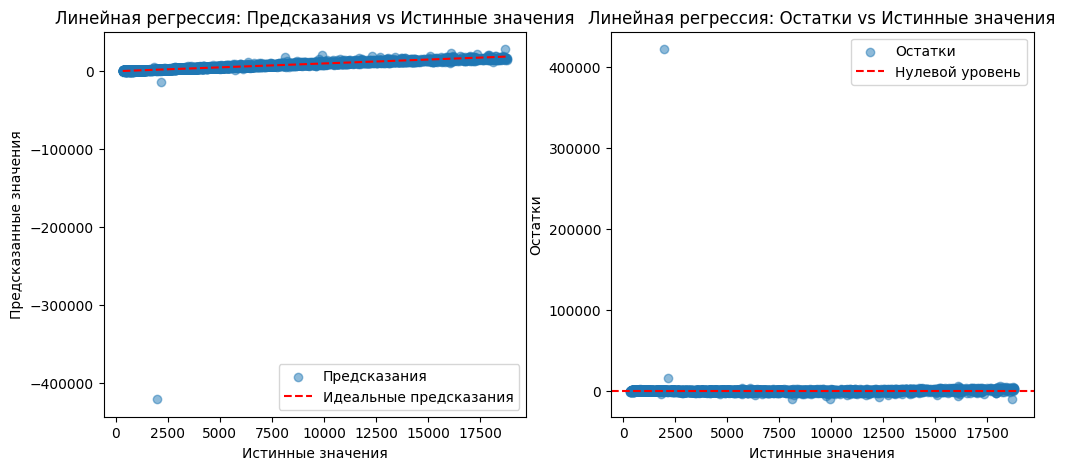

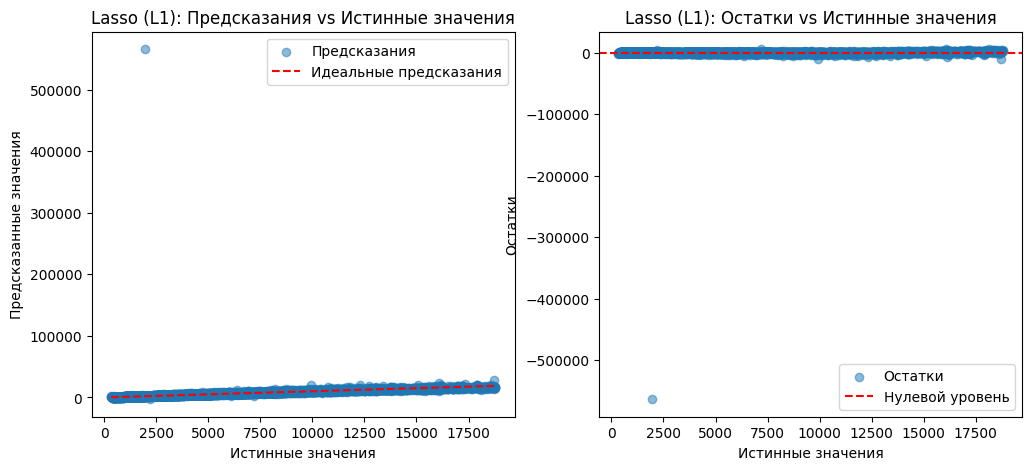

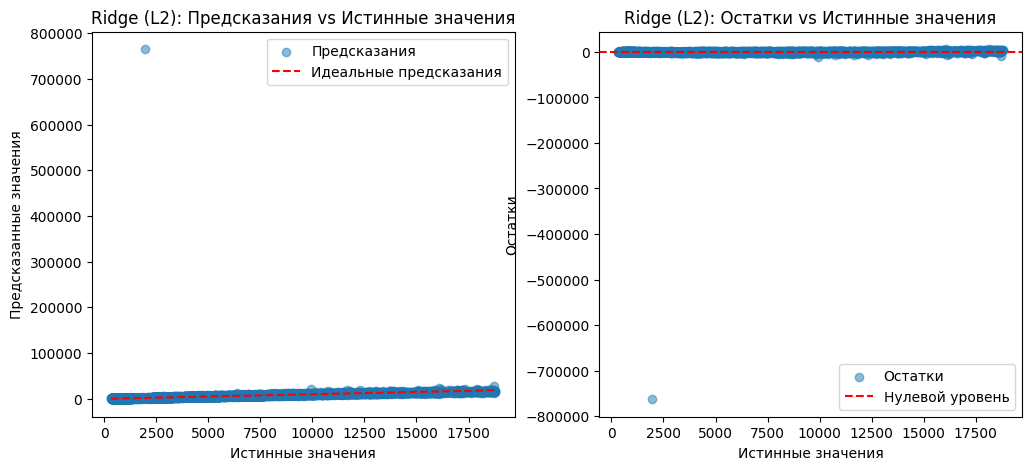

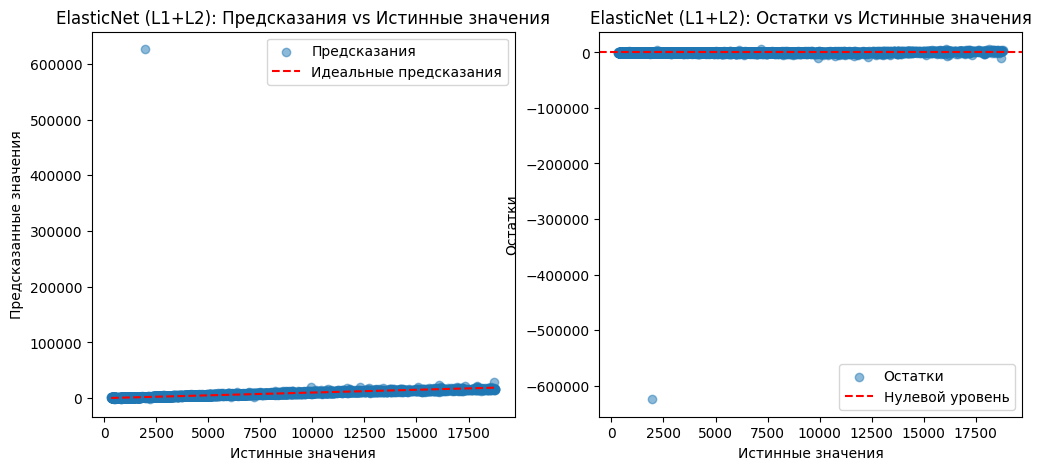

In [20]:
p_models = {
    "Линейная регрессия": model_p_lr,
    "Lasso (L1)": model_p_lasso,
    "Ridge (L2)": model_p_ridge,
    "ElasticNet (L1+L2)": model_p_elastic
}

# Построение графиков для каждой модели
for name, model in p_models.items():
    y_pred = model.predict(x_test_poly)
    plot_predictions(y_test, y_pred, name)

# Шаг 5. Оценка качества моделей

In [21]:
results = []

for name, model in all_models.items():
    if 'Simple' in name:
        y_pred = model.predict(x_test_mono)
    elif 'Poly' in name:
        y_pred = model.predict(x_test_poly)
    else:
        y_pred = model.predict(x_test)
    
    results.append([
        name,
        mean_absolute_error(y_test, y_pred),
        mean_squared_error(y_test, y_pred),
        np.sqrt(mean_squared_error(y_test, y_pred)),
        mean_absolute_percentage_error(y_test, y_pred) * 100,
        r2_score(y_test, y_pred)
    ])

metrics = pd.DataFrame(results, columns=['Regressor', 'MAE', 'MSE', 'RMSE', 'MAPE (%)', 'R^2'])
metrics


,Regressor,MAE,MSE,RMSE,MAPE (%),R^2
0,Simple Linear Regression,996.666113,2.317072e+06,1522.193279,38.055110,0.847982
1,Simple Lasso,996.237223,2.317088e+06,1522.198528,37.986428,0.847981
2,Simple Ridge,996.295353,2.317086e+06,1522.197639,37.995771,0.847981
3,Simple ElasticNet,996.119727,2.317094e+06,1522.200492,37.967540,0.847980
4,Linear Regression,785.483605,1.447354e+06,1203.060448,42.404092,0.905042
5,Lasso,787.868506,1.442515e+06,1201.047585,42.577918,0.905360
6,Ridge,787.669337,1.428128e+06,1195.042919,42.555108,0.906304
7,ElasticNet,788.518100,1.440601e+06,1200.250596,42.625486,0.905485
8,Poly Linear Regression,487.015475,1.714139e+07,4140.216225,20.883946,-0.124610
9,Poly Lasso,500.411285,3.005992e+07,5482.692403,21.853092,-0.972168


# Шаг 6. Реализация пользовательских функций

In [22]:
from funcs.metrics import *

In [23]:
y_pred = model_s_lr.predict(x_test_mono)

print(f'sklearn MAE: {mean_absolute_error(y_test, y_pred)}')
print(f'sklearn MSE: {mean_squared_error(y_test, y_pred)}')
print(f'sklearn RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}')
print(f'sklearn MAPE: {mean_absolute_percentage_error(y_test, y_pred) * 100}')
print(f'sklearn R^2: {r2_score(y_test, y_pred)}')

print(f'my MAE: {MAE(y_test, y_pred)}')
print(f'my MSE: {MSE(y_test, y_pred)}')
print(f'my RMSE: {RMSE(y_test, y_pred)}')
print(f'my MAPE: {MAPE(y_test, y_pred)}')
print(f'my R^2: {R2(y_test, y_pred)}')

sklearn MAE: 996.6661129836585
sklearn MSE: 2317072.379640949
sklearn RMSE: 1522.1932793311594
sklearn MAPE: 38.055109642886805
sklearn R^2: 0.8479817802699159
my MAE: 996.6661129836585
my MSE: 2317072.379640949
my RMSE: 1522.1932793311594
my MAPE: 0.38055109642886803
my R^2: 0.8479817802699159


# Шаг 7. Создание таблицы результатов

In [24]:
def calculate_sklearn_metrics(y_true, y_pred):
    r2 = f"{r2_score(y_true, y_pred):.2f}"
    mse = f"{mean_squared_error(y_true, y_pred):.4f}"
    rmse = f"{np.sqrt(mean_squared_error(y_true, y_pred)):.4f}"
    mae = f"{mean_absolute_error(y_true, y_pred):.4f}"
    mape = f"{mean_absolute_percentage_error(y_true, y_pred):.4f}"
    return r2, mse, rmse, mae, mape

def calculate_my_metrics(y_true, y_pred):
    r2 = f"{R2(y_true, y_pred):.2f}"
    mse = f"{MSE(y_true, y_pred):.4f}"
    rmse = f"{RMSE(y_true, y_pred):.4f}"
    mae = f"{MAE(y_true, y_pred):.4f}"
    mape = f"{MAPE(y_true, y_pred):.4f}"
    return r2, mse, rmse, mae, mape

regressor_names = []
sklearn_metrics = []
custom_metrics = []

for model_name, model in all_models.items():
    if 'Simple' in model_name:
        y_train_pred = model.predict(x_train_mono)
        y_test_pred = model.predict(x_test_mono)
    elif 'Poly' in model_name:
        y_train_pred = model.predict(x_train_poly)
        y_test_pred = model.predict(x_test_poly)
    else:
        y_train_pred = model.predict(x_train)
        y_test_pred = model.predict(x_test)

    regressor_names.append(model_name)

    sklearn_train_metrics = calculate_sklearn_metrics(y_train, y_train_pred)
    sklearn_test_metrics = calculate_sklearn_metrics(y_test, y_test_pred)

    custom_train_metrics = calculate_my_metrics(y_train, y_train_pred)
    custom_test_metrics = calculate_my_metrics(y_test, y_test_pred)

    sklearn_metrics.append(sklearn_train_metrics + sklearn_test_metrics)
    custom_metrics.append(sklearn_test_metrics + custom_test_metrics)

columns = ['R^2', 'MSE', 'RMSE', 'MAE', 'MAPE']
final_df_train_test = pd.DataFrame(sklearn_metrics, columns=columns * 2)
final_df_train_test.insert(0, 'Regressor', regressor_names)

final_df_sklearn_custom = pd.DataFrame(custom_metrics, columns=['Sklearn ' + col for col in columns] + ['Custom ' + col for col in columns])
final_df_sklearn_custom.insert(0, 'Regressor', regressor_names)

In [25]:
final_df_train_test

,Regressor,R^2,MSE,RMSE,MAE,MAPE,R^2,MSE,RMSE,MAE,MAPE
0,Simple Linear Regression,0.85,2417764.1507,1554.9161,1010.3942,0.3819,0.85,2317072.3796,1522.1933,996.6661,0.3806
1,Simple Lasso,0.85,2417768.8418,1554.9176,1009.9544,0.3812,0.85,2317088.3585,1522.1985,996.2372,0.3799
2,Simple Ridge,0.85,2417767.6474,1554.9172,1010.0141,0.3813,0.85,2317085.6519,1522.1976,996.2954,0.3800
3,Simple ElasticNet,0.85,2417771.7928,1554.9186,1009.8338,0.3810,0.85,2317094.3389,1522.2005,996.1197,0.3797
4,Linear Regression,0.91,1492257.0366,1221.5797,804.6818,0.4368,0.91,1447354.4419,1203.0604,785.4836,0.4240
5,Lasso,0.91,1492536.3249,1221.6940,807.2038,0.4388,0.91,1442515.3022,1201.0476,787.8685,0.4258
6,Ridge,0.91,1492883.9190,1221.8363,807.3382,0.4388,0.91,1428127.5782,1195.0429,787.6693,0.4256
7,ElasticNet,0.91,1492704.6771,1221.7629,807.9022,0.4394,0.91,1440601.4942,1200.2506,788.5181,0.4263
8,Poly Linear Regression,0.96,576677.1814,759.3926,456.9422,0.1931,-0.12,17141390.3909,4140.2162,487.0155,0.2088
9,Poly Lasso,0.96,587510.1381,766.4921,458.7319,0.1960,-0.97,30059915.9834,5482.6924,500.4113,0.2185


In [26]:
final_df_sklearn_custom

,Regressor,Sklearn R^2,Sklearn MSE,Sklearn RMSE,Sklearn MAE,Sklearn MAPE,Custom R^2,Custom MSE,Custom RMSE,Custom MAE,Custom MAPE
0,Simple Linear Regression,0.85,2317072.3796,1522.1933,996.6661,0.3806,0.85,2317072.3796,1522.1933,996.6661,0.3806
1,Simple Lasso,0.85,2317088.3585,1522.1985,996.2372,0.3799,0.85,2317088.3585,1522.1985,996.2372,0.3799
2,Simple Ridge,0.85,2317085.6519,1522.1976,996.2954,0.3800,0.85,2317085.6519,1522.1976,996.2954,0.3800
3,Simple ElasticNet,0.85,2317094.3389,1522.2005,996.1197,0.3797,0.85,2317094.3389,1522.2005,996.1197,0.3797
4,Linear Regression,0.91,1447354.4419,1203.0604,785.4836,0.4240,0.91,1447354.4419,1203.0604,785.4836,0.4240
5,Lasso,0.91,1442515.3022,1201.0476,787.8685,0.4258,0.91,1442515.3022,1201.0476,787.8685,0.4258
6,Ridge,0.91,1428127.5782,1195.0429,787.6693,0.4256,0.91,1428127.5782,1195.0429,787.6693,0.4256
7,ElasticNet,0.91,1440601.4942,1200.2506,788.5181,0.4263,0.91,1440601.4942,1200.2506,788.5181,0.4263
8,Poly Linear Regression,-0.12,17141390.3909,4140.2162,487.0155,0.2088,-0.12,17141390.3909,4140.2162,487.0155,0.2088
9,Poly Lasso,-0.97,30059915.9834,5482.6924,500.4113,0.2185,-0.97,30059915.9834,5482.6924,500.4113,0.2185


# Шаг 8. Вывод
В ходе лабораторной работы я изучил работу разных моделей регрессии, а так же узнал о метриках, гиперпараметрах и на практике закрепил полученные знания. Анализируя полученные данные в последней таблице могу заметить, что наиболее точные _предсказания_ получаются у модели **Ridge** (регрессия с регуляризацией L-2).